:# BuildFlowMatch - demo

Pasi: clone repo -> instalare dependințe -> parametrii model + encoder dav2 -> incarcare set de date (poze + ground truth) -> demo fine-tuning-> demo inferență

## 1. Clonare repo

In [ ]:
REPO_URL = "https://github.com/rosemariestoica13/BuildFlowMatch.git"

!git clone $REPO_URL buildflowmatch
%cd buildflowmatch

Cloning into 'buildflowmatch'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 101 (delta 31), reused 86 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 539.23 KiB | 12.25 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/buildflowmatch/buildflowmatch/buildflowmatch/buildflowmatch


## 2. Instalare dependinte

In [ ]:
!pip install -q -r requirements.txt

## 3. Checkpoint-uri (BuildFlowMatch + encoder dav2)
Se descarcă automat din folderul Google Drive:
https://drive.google.com/drive/folders/1jg476sKB1r9xMA2ecoMvWVLHDtpl5HMi

In [ ]:
!pip install -q gdown

import os, shutil, gdown

FOLDER_URL = "https://drive.google.com/drive/folders/1jg476sKB1r9xMA2ecoMvWVLHDtpl5HMi"

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('depth-anything-ckpts', exist_ok=True)

gdown.download_folder(url=FOLDER_URL, output='drive_ckpts', quiet=False, use_cookies=False)

for fname in os.listdir('drive_ckpts'):
    src = os.path.join('drive_ckpts', fname)
    if 'depth_anything' in fname.lower():
        shutil.move(src, os.path.join('depth-anything-ckpts', fname))
    else:
        shutil.move(src, os.path.join('checkpoints', 'sintel-gm-final.pth'))

print('checkpoints/:', os.listdir('checkpoints'))
print('depth-anything-ckpts/:', os.listdir('depth-anything-ckpts'))

Retrieving folder contents


Processing file 1WqBFsyrFZmQKDh1Tcd8en_a9f_QzJdLn depth_anything_v2_vits.pth
Processing file 12MUTZLBScez7uLwRsMuxveYVyM3mz2pp final.pth


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1WqBFsyrFZmQKDh1Tcd8en_a9f_QzJdLn
From (redirected): https://drive.google.com/uc?id=1WqBFsyrFZmQKDh1Tcd8en_a9f_QzJdLn&confirm=t&uuid=1e5bcb60-bde9-4dba-85b9-ef3f85ecea9b
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/buildflowmatch/drive_ckpts/depth_anything_v2_vits.pth
100%|██████████| 99.2M/99.2M [00:00<00:00, 203MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=12MUTZLBScez7uLwRsMuxveYVyM3mz2pp
From (redirected): https://drive.google.com/uc?id=12MUTZLBScez7uLwRsMuxveYVyM3mz2pp&confirm=t&uuid=575d892c-7fbc-46a0-bf2d-7ba25430c4ca
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/buildflowmatch/drive_ckpts/final.pth
100%|██████████| 229M/229M [00:04<00:00, 51.2MB/s]

checkpoints/: ['.gitkeep', 'sintel-gm-final.pth']
depth-anything-ckpts/: ['.gitkeep', 'depth_anything_v2_vits.pth']



Download completed


## 5. Setul tau de date (poze + ground truth) din Google Drive
Se descarca automat din folderul Google Drive:
https://drive.google.com/drive/folders/1w0Y16win5utMvTPW0ryLbQSUv93ojEon

Folderul conține 3 fisiere (două cadre și ground truth-ul) din data set-ul KITTI: `xxxxxx_10.png` (image1), `xxxxxx_11.png` (image2) si `xxxxxx_10_gt.png`
(ground truth, format KITTI 16-bit — vezi `dataloader/custom.py`).

In [ ]:
!pip install -q gdown

import os, shutil, gdown

DATA_FOLDER_URL = "https://drive.google.com/drive/folders/1w0Y16win5utMvTPW0ryLbQSUv93ojEon"

for sub in ('image1', 'image2', 'flow'):
    os.makedirs(f'data/custom/{sub}', exist_ok=True)

gdown.download_folder(url=DATA_FOLDER_URL, output='drive_data', quiet=False, use_cookies=False)

for fname in sorted(os.listdir('drive_data')):
    src = os.path.join('drive_data', fname)
    stem = os.path.splitext(fname)[0]
    if stem.endswith('_gt'):
        dst = os.path.join('data/custom/flow', fname)
    elif stem.endswith('_11'):
        dst = os.path.join('data/custom/image2', fname)
    elif stem.endswith('_10'):
        dst = os.path.join('data/custom/image1', fname)
    else:
        raise ValueError(f"Nu stiu unde sa pun {fname} (astept sufix _10, _11 sau _gt)")
    shutil.move(src, dst)

print('image1:', os.listdir('data/custom/image1'))
print('image2:', os.listdir('data/custom/image2'))
print('flow:  ', os.listdir('data/custom/flow'))

Retrieving folder contents


Processing file 1bEaE4vJL09ujwhBT6R4g6Wvl1JtIBoHY 000013_10_gt.png
Processing file 1IWMsSuNQfYg9CKaCsy9S4b2C1adOEJB0 000013_10.png
Processing file 1vWu2lDqYJqh2_QFF3anSBH_Lm7w3VMaD 000013_11.png


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1bEaE4vJL09ujwhBT6R4g6Wvl1JtIBoHY
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/buildflowmatch/drive_data/000013_10_gt.png
100%|██████████| 403k/403k [00:00<00:00, 108MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IWMsSuNQfYg9CKaCsy9S4b2C1adOEJB0
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/buildflowmatch/drive_data/000013_10.png
100%|██████████| 832k/832k [00:00<00:00, 144MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vWu2lDqYJqh2_QFF3anSBH_Lm7w3VMaD
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/buildflowmatch/drive_data/000013_11.png
100%|██████████| 834k/834k [00:00<00:00, 140MB/s]

image1: ['000013_10.png']
image2: ['000013_11.png']
flow:   ['000013_10_gt.png']



Download completed


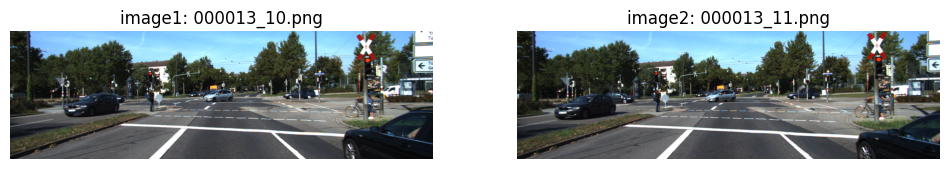

In [ ]:
import matplotlib.pyplot as plt
import cv2
from glob import glob

img1_path = sorted(glob('data/custom/image1/*'))[0]
img2_path = sorted(glob('data/custom/image2/*'))[0]

img1 = cv2.cvtColor(cv2.imread(img1_path), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(img2_path), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1); ax[0].set_title(f'image1: {os.path.basename(img1_path)}'); ax[0].axis('off')
ax[1].imshow(img2); ax[1].set_title(f'image2: {os.path.basename(img2_path)}'); ax[1].axis('off')
plt.show()

## 6. Fine-tuning
Rulează pași de antrenare pornind de la checkpoint, pe setul tău de date.

In [ ]:
!python finetune_demo.py \
    --cfg config/a2/dav2/sintel-gm.json \
    --ckpt checkpoints/sintel-gm-final.pth \
    --data_dir data/custom \
    --steps 100 \
    --out_ckpt checkpoints/finetuned.pth

xFormers not available
xFormers not available
64
Loaded checkpoint from checkpoints/sintel-gm-final.pth
Custom dataset: 1 image pair(s) found in data/custom
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[demo_out/flow_before.jpg] EPE vs ground truth: 1.081
step 0000 | loss 7.5316 | epe 6.953
step 0001 | loss 5.3535 | epe 1.335
step 0002 | loss 5.0885 | epe 1.065
step 0003 | loss 4.5982 | epe 0.818
step 0004 | loss 4.0405 | epe 0.649
step 0005 | loss 4.0353 | epe 0.657
step 0006 | loss 3.9531 | epe 0.580
step 0007 | loss 3.7239 | epe 0.511
step 0008 | loss 3.8329 | epe 0.539
step 0009 | loss 3.8019 | epe 0.513
step 0010 | loss 3.6226 | epe 0.483
step 0011 | loss 3.7467 | epe 0.516
step 0012 | loss 3.8602 | epe 0.554
ste

## 8. Inferenta pe imagini noi (fara ground truth)
Se descarca o pereche de imagini fara flux optic de referinta din folderul:
https://drive.google.com/drive/folders/1UGqKcwzKAb35TGcCYyLwKqEqzvMXjwZi

Ruleaza inferenta cu checkpoint-ul fine-tuned (`checkpoints/finetuned.pth`).

In [ ]:
!pip install -q gdown

import os, gdown

INFER_FOLDER_URL = "https://drive.google.com/drive/folders/1UGqKcwzKAb35TGcCYyLwKqEqzvMXjwZi"

os.makedirs('infer_data', exist_ok=True)
gdown.download_folder(url=INFER_FOLDER_URL, output='infer_data', quiet=False, use_cookies=False)

print(sorted(os.listdir('infer_data')))

Retrieving folder contents


Processing file 1gqONppuLOelSd8aswp32Urgm2DY0Yuio 000008_10.png
Processing file 1Y9rVCBqulywueBdkVNO-FuqbCR3PTuFY 000008_11.png


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1gqONppuLOelSd8aswp32Urgm2DY0Yuio
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/buildflowmatch/infer_data/000008_10.png
100%|██████████| 849k/849k [00:00<00:00, 113MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Y9rVCBqulywueBdkVNO-FuqbCR3PTuFY
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/buildflowmatch/infer_data/000008_11.png
100%|██████████| 854k/854k [00:00<00:00, 105MB/s]

['000008_10.png', '000008_11.png']



Download completed


In [ ]:
imgs = sorted(os.listdir('infer_data'))

!python infer_demo.py \
    --cfg config/a2/dav2/sintel-gm.json \
    --ckpt checkpoints/finetuned.pth \
    --img1 infer_data/{imgs[0]} \
    --img2 infer_data/{imgs[1]} \
    --out demo_out/infer_flow.jpg

xFormers not available
xFormers not available
64
Loaded checkpoint from checkpoints/finetuned.pth
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Saved flow visualization to demo_out/infer_flow.jpg


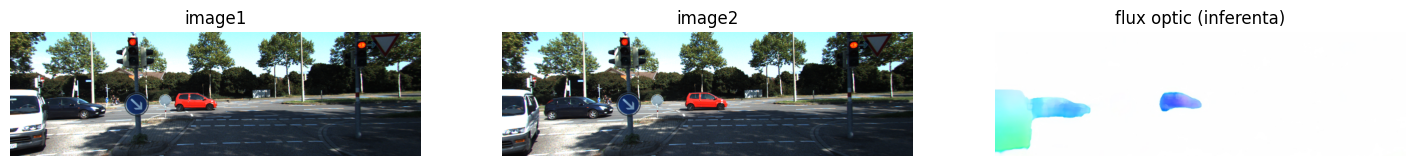

In [ ]:
import matplotlib.pyplot as plt
import cv2

img1 = cv2.cvtColor(cv2.imread(f'infer_data/{imgs[0]}'), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(f'infer_data/{imgs[1]}'), cv2.COLOR_BGR2RGB)
flow_vis = cv2.cvtColor(cv2.imread('demo_out/infer_flow.jpg'), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img1); ax[0].set_title('image1'); ax[0].axis('off')
ax[1].imshow(img2); ax[1].set_title('image2'); ax[1].axis('off')
ax[2].imshow(flow_vis); ax[2].set_title('flux optic (inferenta)'); ax[2].axis('off')
plt.show()